In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

X_test = np.load('../data/processed/X_test_processed.npy')
y_test = np.load('../data/processed/y_test.npy')

model = joblib.load('../models/xgb_model.pkl')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month']

cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

preprocessor = joblib.load('../models/preprocessor.pkl')
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

X_test_df = pd.DataFrame(X_test, columns=all_feature_names)

print(f"test samples: {X_test_df.shape[0]}")
print(f"features: {X_test_df.shape[1]}")
print(f"feature names sample: {all_feature_names[:6]}")

test samples: 1407
features: 35
feature names sample: ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_month', 'MultipleLines_No', 'MultipleLines_No phone service']


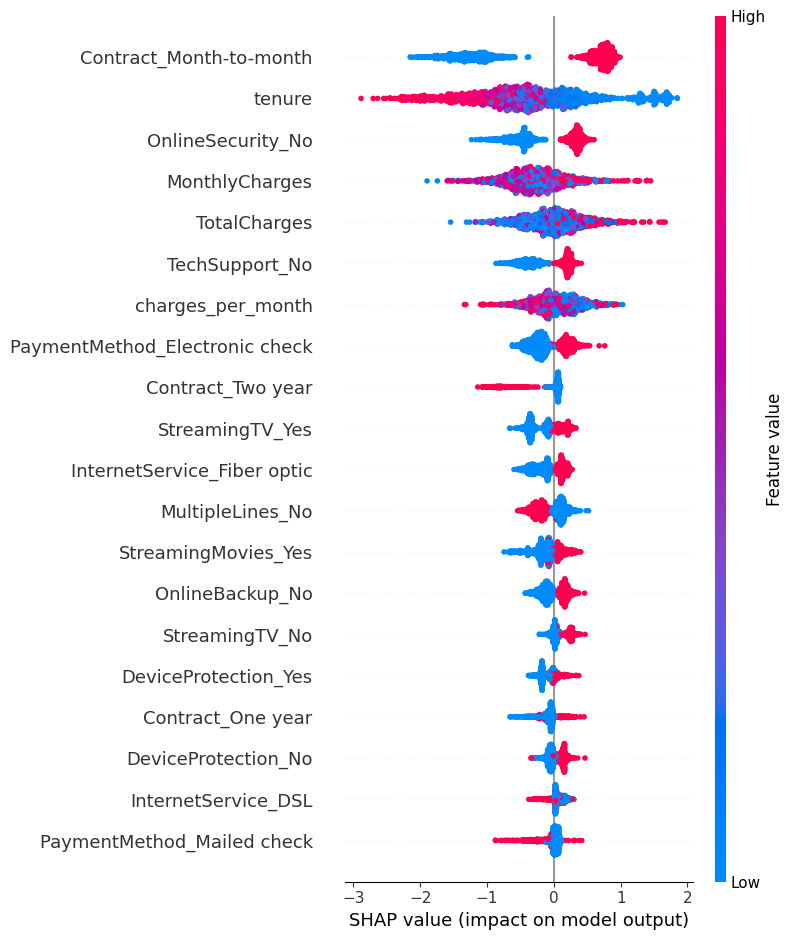

In [6]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

X_test_df = pd.DataFrame(X_test, columns=all_feature_names)
shap.summary_plot(shap_values, X_test_df)

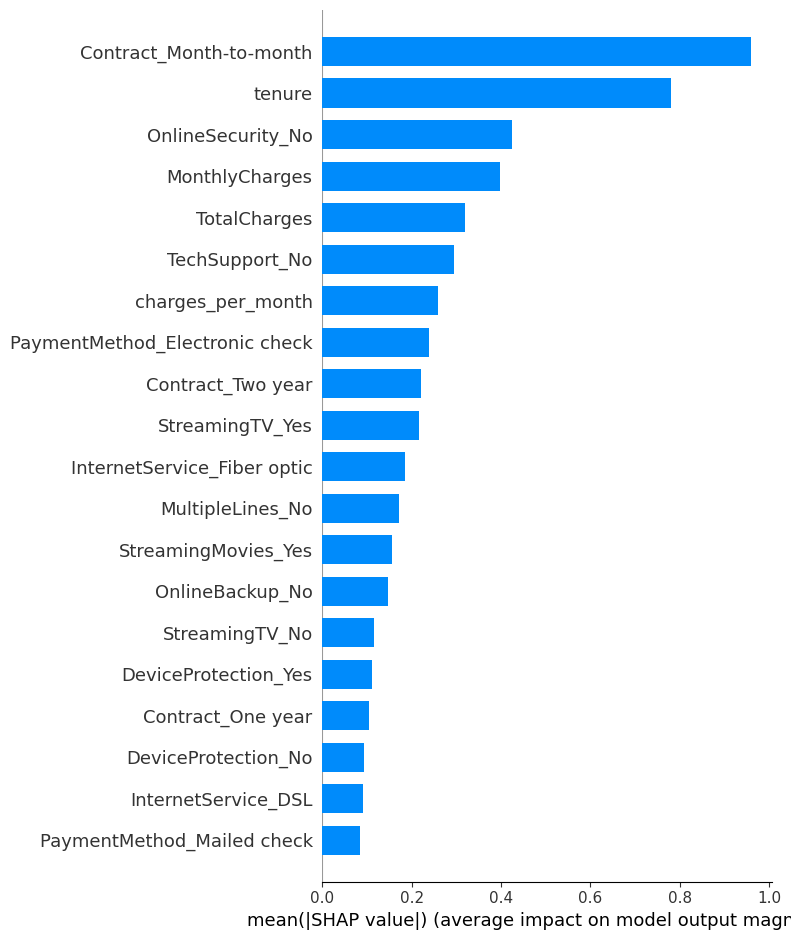

In [7]:
shap.summary_plot(plot_type="bar", shap_values=shap_values, features=X_test_df, feature_names=all_feature_names)

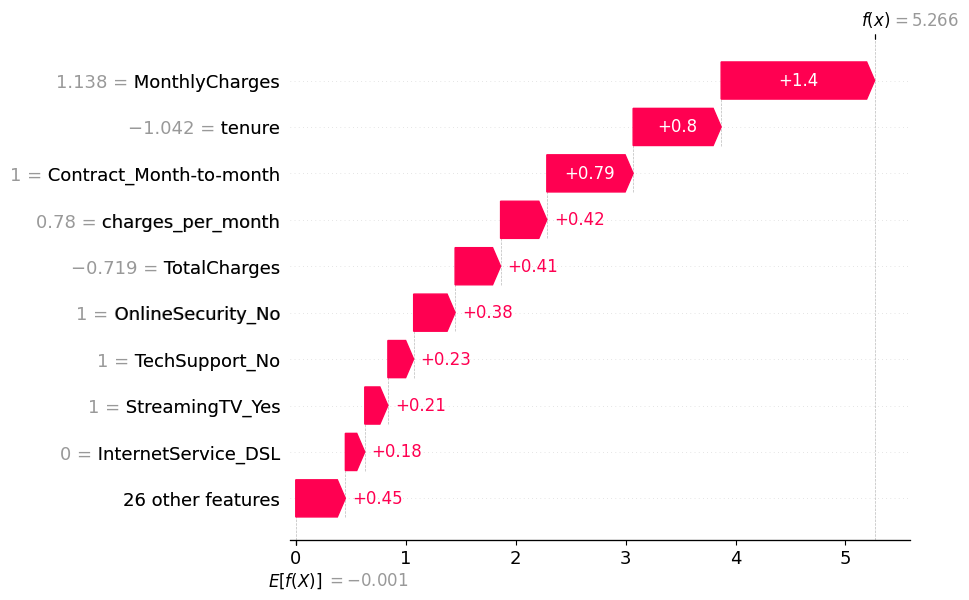

In [8]:
high_risk_idx = np.argmax(model.predict_proba(X_test)[:, 1])

explanation = shap.Explanation(
    values    = shap_values[high_risk_idx],
    base_values = explainer.expected_value,
    data      = X_test_df.iloc[high_risk_idx],
    feature_names = all_feature_names
)
shap.plots.waterfall(explanation)

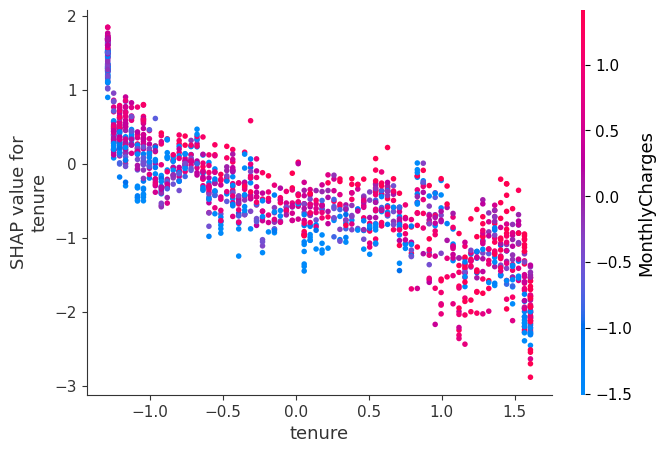

In [9]:
shap.dependence_plot('tenure', shap_values, X_test_df)